# OSC AlphaGenome setup
## imports

In [2]:
from alphagenome_research.model import dna_model
from alphagenome import colab_utils
from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript
from alphagenome.data import ontology
from alphagenome.interpretation import ism
from alphagenome.models import dna_client
from alphagenome.models import variant_scorers
from alphagenome.visualization import plot_components

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
from pysam import VariantFile
from io import StringIO
from tqdm import tqdm
import os
import gc
from dotenv import load_dotenv


# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE']='true'
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.9' # pre allocates XX% of total GPU instead of the default 75%

pd.set_option('display.max_columns', None)
load_dotenv(dotenv_path=".env")
API_KEYS = [v for _, v in sorted(
    ((k, os.environ[k].strip()) for k in os.environ
     if k.startswith("AG_API_KEY_") and k.removeprefix("AG_API_KEY_").isdigit()),
    key=lambda kv: int(kv[0].removeprefix("AG_API_KEY_")),
) if v]


## common variables

In [22]:
LMNA_START = 156_082_572
LMNA_END = 156_140_081
gene_symbol = "LMNA"
LMNA_INTERVAL = genome.Interval('chr1', 156_082_572, 156_140_081)


BASE_PATH = '/users/PAS2905/coraalbers/'
AG_DATA_PATH = '/users/PAS2905/coraalbers/ag/ag_data/'

HG38_FASTA_PATH = '/users/PAS2905/coraalbers/ag/hg38.fa'
HG38_GTF_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.annotation.gtf.gz.feather'
HG38_SPLICE_START_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.splice_sites_starts.feather'
HG38_SPLICE_END_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.splice_sites_ends.feather'
CALIBRATION_PATH = f'{AG_DATA_PATH}calibration_scores.pb'

gtf = pd.read_feather( 'https://storage.googleapis.com/alphagenome/reference/gencode/' 'hg38/gencode.v46.annotation.gtf.gz.feather' )

output_modalities = ['atac',	
    'cage',	
    'chip_histone',	
    'chip_tf',	
    'contact_maps',	
    'dnase',	
    'procap',	
    'rna_seq',	
    'splice_junctions',	
    'splice_site_usage',	
    'splice_sites']

requested_outputs = {dna_client.OutputType.ATAC,
        dna_client.OutputType.CAGE,
        dna_client.OutputType.DNASE,
        dna_client.OutputType.PROCAP,
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.SPLICE_SITES,
        dna_client.OutputType.SPLICE_SITE_USAGE,
        dna_client.OutputType.SPLICE_JUNCTIONS,
        dna_client.OutputType.CONTACT_MAPS,
        dna_client.OutputType.CHIP_HISTONE,
        dna_client.OutputType.CHIP_TF}

ccre_bed_path = f'{BASE_PATH}ag/variant-effects/osc/data_sync/predicted_ccre_like_regions_central_LV_128res.bed'

## model initialization

In [3]:
# all_folds_model = dna_model.create_from_huggingface( 'all_folds',
#     organism_settings={ 
#         dna_model.Organism.HOMO_SAPIENS: dna_model.OrganismSettings( 
#             fasta_path=HG38_FASTA_PATH, 
#             gtf_feather_path=HG38_GTF_PATH, 
#             splice_site_starts_feather_path=HG38_SPLICE_START_PATH, 
#             splice_site_ends_feather_path=HG38_SPLICE_END_PATH, 
#             calibration_path=CALIBRATION_PATH,
#         ), dna_model.Organism.MUS_MUSCULUS: dna_model.OrganismSettings() } 
# )

model = dna_client.create(API_KEYS[5])


print('all folds model initialized!')

all folds model initialized!


# import cCRE bed file

In [28]:
ccre_df = pd.read_csv(ccre_bed_path, sep='\t')
ccre_df['start'] = ccre_df['start'].astype(int)
ccre_df['end'] = ccre_df['end'].astype(int)
ccre_df.head()

,chrom,start,end,name,score,cCRE_class,d_tss,high_CA,high_H3K4me3,high_H3K27ac,high_CTCF,high_TF,max_CA,max_H3K4me3,max_H3K27ac,max_CTCF,max_TF
0,chr1,156338015,156338911,pred_ccre_central_0_Distal enhancer,19.720718,Distal enhancer,200763,True,True,True,True,True,19.720718,7.782745,3.437913,0.435852,9.092731
1,chr1,156052959,156055391,pred_ccre_central_1_Distal enhancer,18.748081,Distal enhancer,28396,True,True,True,True,True,18.748081,8.692101,7.210982,9.786079,7.372068
2,chr1,156456415,156457823,pred_ccre_central_2_Distal enhancer,18.621325,Distal enhancer,319419,True,True,True,True,True,18.621325,5.600292,10.808559,11.645118,8.048043
3,chr1,156282335,156283103,pred_ccre_central_3_Distal enhancer,17.011522,Distal enhancer,145019,True,True,True,True,True,17.011522,9.146778,5.850923,0.362469,12.718414
4,chr1,156193503,156194271,pred_ccre_central_4_Distal enhancer,16.304649,Distal enhancer,56187,True,True,True,True,True,16.304649,7.464471,3.459850,6.997523,6.941903


# get ISM scores

In [29]:
ism_scores_dir = f'{BASE_PATH}ag/variant-effects/osc/lmna_ism_out/'

ism_dfs = []

for idx, row in ccre_df.iterrows():
    start = row.start
    end = row.end
    ism_results_path = f'{ism_scores_dir}lmna_ism_{start}_{end}_1048576.csv'
    ism_results_df = pd.read_csv(ism_results_path) 
    ism_results_df['ccre_id'] = row['name']
    ism_dfs.append(ism_results_df)

In [51]:
ism_df = pd.concat(ism_dfs, ignore_index=True)
# ism_df['ccre_id'].unique()
ism_df.head()

,position,ref,alt,"ATAC, RECOMMENDED","CONTACT_MAPS, RECOMMENDED","DNASE, RECOMMENDED","CHIP_TF, RECOMMENDED","CHIP_HISTONE, RECOMMENDED","CAGE, RECOMMENDED","PROCAP, RECOMMENDED","RNA_SEQ, RECOMMENDED","RNA_SEQ_ACTIVE, RECOMMENDED","SPLICE_SITES, RECOMMENDED","SPLICE_SITE_USAGE, RECOMMENDED","SPLICE_JUNCTIONS, RECOMMENDED","POLYADENYLATION, RECOMMENDED","ATAC_ACTIVE, RECOMMENDED","DNASE_ACTIVE, RECOMMENDED","CHIP_TF_ACTIVE, RECOMMENDED","CHIP_HISTONE_ACTIVE, RECOMMENDED","CAGE_ACTIVE, RECOMMENDED","PROCAP_ACTIVE, RECOMMENDED",ccre_id
0,156338016,A,C,-0.019206,0.001292,-0.003233,-0.009266,-0.004895,-0.032515,NaN,-0.003047,4.078962,NaN,NaN,NaN,NaN,243.861633,247.741623,2113.5,41200.0,6171.812012,NaN,pred_ccre_central_0_Distal enhancer
1,156338016,A,G,0.013508,0.001490,0.049021,0.011214,0.006639,0.016647,NaN,-0.002563,4.078962,NaN,NaN,NaN,NaN,246.165100,256.338745,2130.0,41384.0,6243.448730,NaN,pred_ccre_central_0_Distal enhancer
2,156338016,A,T,-0.003419,0.001259,-0.006300,-0.000341,0.004144,-0.028249,NaN,-0.003906,4.078962,NaN,NaN,NaN,NaN,243.861633,247.741623,2113.5,41194.0,6171.812012,NaN,pred_ccre_central_0_Distal enhancer
3,156338017,C,A,-0.027737,0.001741,-0.029873,-0.032429,-0.011247,-0.038262,NaN,-0.003596,4.078962,NaN,NaN,NaN,NaN,244.284454,249.150925,2113.5,41226.0,6309.795898,NaN,pred_ccre_central_0_Distal enhancer
4,156338017,C,G,-0.035234,0.001262,-0.026756,-0.018592,-0.012004,-0.003931,NaN,-0.005064,4.078962,NaN,NaN,NaN,NaN,244.284454,249.150925,2113.5,41232.0,6326.376953,NaN,pred_ccre_central_0_Distal enhancer


In [37]:
ism_df.describe()

,position,"ATAC, RECOMMENDED","CONTACT_MAPS, RECOMMENDED","DNASE, RECOMMENDED","CHIP_TF, RECOMMENDED","CHIP_HISTONE, RECOMMENDED","CAGE, RECOMMENDED","PROCAP, RECOMMENDED","RNA_SEQ, RECOMMENDED","RNA_SEQ_ACTIVE, RECOMMENDED","SPLICE_SITES, RECOMMENDED","SPLICE_SITE_USAGE, RECOMMENDED","SPLICE_JUNCTIONS, RECOMMENDED","POLYADENYLATION, RECOMMENDED","ATAC_ACTIVE, RECOMMENDED","DNASE_ACTIVE, RECOMMENDED","CHIP_TF_ACTIVE, RECOMMENDED","CHIP_HISTONE_ACTIVE, RECOMMENDED","CAGE_ACTIVE, RECOMMENDED","PROCAP_ACTIVE, RECOMMENDED"
count,1.040640e+05,102564.000000,102564.000000,102564.000000,102564.000000,102564.000000,102564.000000,0.0,102564.000000,102564.000000,32508.000000,32508.000000,32508.000000,32508.000000,102564.000000,102564.000000,102564.000000,102564.000000,102564.000000,0.0
mean,1.561698e+08,-0.011005,0.002257,-0.013263,-0.007175,-0.002874,-0.004317,NaN,-0.003128,4.080523,0.023906,0.005268,0.124381,0.004294,455.353120,714.402927,3109.004663,46637.320490,1148.948371,NaN
std,2.383609e+05,0.112003,0.005344,0.132439,0.173915,0.073468,0.231564,NaN,0.006493,0.011463,0.060806,0.028309,0.312361,0.002476,273.752100,561.213754,2761.147861,20804.584422,3013.424676,NaN
min,1.556098e+08,-2.759468,0.000810,-2.935511,-4.810450,-2.701780,-3.390784,NaN,-0.158720,4.078962,0.003906,0.000107,0.023407,0.000000,73.678802,80.549820,819.000000,4577.500000,0.657422,NaN
25%,1.560540e+08,-0.030163,0.001333,-0.034414,-0.029777,-0.019505,-0.063762,NaN,-0.003668,4.078962,0.007812,0.001953,0.044189,0.002799,252.172005,309.937668,1455.000000,34451.000000,6.824430,NaN
50%,1.561159e+08,-0.001362,0.001571,-0.001656,-0.001094,-0.002868,-0.000503,NaN,-0.002885,4.078962,0.009766,0.003906,0.057434,0.003535,363.515396,484.474121,2158.000000,44741.000000,26.043855,NaN
75%,1.564566e+08,0.023061,0.002080,0.025173,0.028873,0.019037,0.064079,NaN,-0.002122,4.078962,0.016602,0.003906,0.100830,0.005305,623.898499,986.843567,3544.000000,61344.000000,244.596954,NaN
max,1.566018e+08,1.181981,0.371245,1.402103,3.423322,1.335144,4.266462,NaN,0.182232,4.752590,0.999839,0.995487,8.429688,0.038012,1535.017090,2781.781738,18040.000000,101536.000000,22188.863281,NaN


# calculate ISM matrix

In [55]:
# Transform tidy ISM rows → ism.ism_matrix (one scorer)
SCORE_COL = 'RNA_SEQ, RECOMMENDED'  # swap as needed
CHROM = 'chr1'

# interval for this cCRE (0-based half-open; matches CSV filename lmna_ism_{start}_{end}_...)
ccre = ccre_df.iloc[0]
ccre_id = ccre['name']
ism_interval = LMNA_INTERVAL # genome.Interval(CHROM, int(ccre.start), int(ccre.end))

df = ism_df.dropna(subset=[SCORE_COL]).copy()

# keep only positions with all 3 alts (avoids require_fully_filled errors)
n_alts = df.groupby('position')['alt'].transform('size')
df = df.loc[n_alts == 3].copy()

variants = [
    genome.Variant(
        chromosome=CHROM,
        position=int(row.position),  # 1-based, as written by the ISM job
        reference_bases=row.ref,
        alternate_bases=row.alt,
    )
    for row in df.itertuples(index=False)
]
scores = df[SCORE_COL].astype(float).tolist()

ism_result = ism.ism_matrix(
    scores,
    variants=variants,
    interval=ism_interval,
    multiply_by_sequence=True,   # nonzeros only at REF bases (logo-style)
    require_fully_filled=False,  # CSV can have unscored / partial positions
)
ism_result.shape, ism_result


((57509, 4),
 array([[-0.        , -0.        ,  0.00202346,  0.        ],
        [ 0.00114379, -0.        , -0.        ,  0.        ],
        [-0.        ,  0.00277114, -0.        ,  0.        ],
        ...,
        [ 0.        ,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ]],
       shape=(57509, 4), dtype=float32))

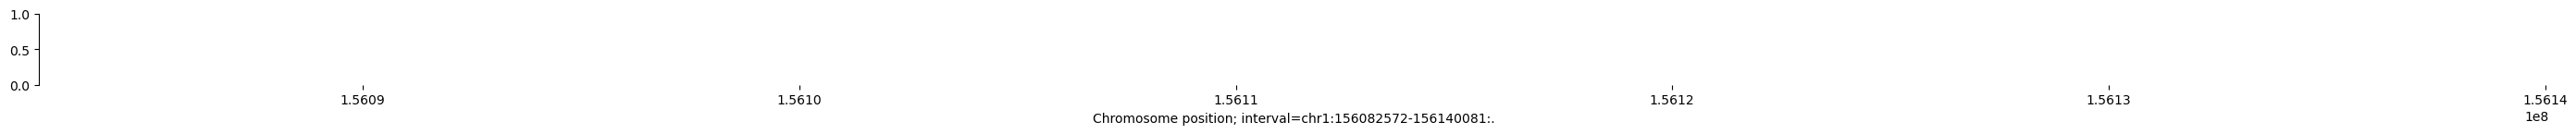

In [56]:
plot_components.plot(
    [
        plot_components.SeqLogo(
            scores=ism_result,
            scores_interval=ism_interval,
            ylabel=f'ISM {ccre_id}',
        )
    ],
    interval=ism_interval,
    fig_width=35,
)

plt.show()



In [ ]:
# Optional: build one ISM matrix per non-empty scorer column
score_cols = [c for c in test.columns if c.endswith('RECOMMENDED')]
ism_by_scorer = {}
for col in score_cols:
    d = test.dropna(subset=[col])
    d = d.loc[d.groupby('position')['alt'].transform('size') == 3]
    if d.empty:
        continue
    vs = [
        genome.Variant(
            chromosome=CHROM,
            position=int(r.position),
            reference_bases=r.ref,
            alternate_bases=r.alt,
        )
        for r in d.itertuples(index=False)
    ]
    ism_by_scorer[col] = ism.ism_matrix(
        d[col].astype(float).tolist(),
        variants=vs,
        interval=ism_interval,
        require_fully_filled=False,
    )

{k: v.shape for k, v in ism_by_scorer.items()}


In [57]:
SCORE_COL = 'RNA_SEQ, RECOMMENDED'

# Top 1% by |quantile_score| within each output_type (extreme pos or neg)
q = 0.99

abs_score = ism_df[SCORE_COL].abs()
ism_thresh = abs_score.groupby(ism_df['ccre_id']).transform('quantile', q=q)
ism_df_top1 = ism_df[abs_score >= ism_thresh].copy().reset_index()

print(ism_df.groupby('ccre_id').size().rename('n_all').to_frame()
      .join(ism_df_top1.groupby('ccre_id').size().rename('n_top1%')))



                                        n_all  n_top1%
ccre_id                                               
pred_ccre_central_0_Distal enhancer      2688       27
pred_ccre_central_10_Proximal enhancer   2688       27
pred_ccre_central_11_Distal enhancer     1536       16
pred_ccre_central_12_Promoter            3072       31
pred_ccre_central_13_Proximal enhancer   6528       66
pred_ccre_central_14_Distal enhancer     3840       39
pred_ccre_central_15_Proximal enhancer   4224       43
pred_ccre_central_16_CA-CTCF             2304       24
pred_ccre_central_17_CA-H3K4me3          1536       16
pred_ccre_central_18_Distal enhancer     1536       16
pred_ccre_central_19_Distal enhancer     1536       16
pred_ccre_central_1_Distal enhancer      7296       73
pred_ccre_central_20_Distal enhancer     4608       47
pred_ccre_central_21_Distal enhancer     2688       27
pred_ccre_central_22_Distal enhancer     1920       20
pred_ccre_central_23_Proximal enhancer   1536       16
pred_ccre_

In [58]:
ism_df_top1

,index,position,ref,alt,"ATAC, RECOMMENDED","CONTACT_MAPS, RECOMMENDED","DNASE, RECOMMENDED","CHIP_TF, RECOMMENDED","CHIP_HISTONE, RECOMMENDED","CAGE, RECOMMENDED","PROCAP, RECOMMENDED","RNA_SEQ, RECOMMENDED","RNA_SEQ_ACTIVE, RECOMMENDED","SPLICE_SITES, RECOMMENDED","SPLICE_SITE_USAGE, RECOMMENDED","SPLICE_JUNCTIONS, RECOMMENDED","POLYADENYLATION, RECOMMENDED","ATAC_ACTIVE, RECOMMENDED","DNASE_ACTIVE, RECOMMENDED","CHIP_TF_ACTIVE, RECOMMENDED","CHIP_HISTONE_ACTIVE, RECOMMENDED","CAGE_ACTIVE, RECOMMENDED","PROCAP_ACTIVE, RECOMMENDED",ccre_id
0,4,156338017,C,G,-0.035234,0.001262,-0.026756,-0.018592,-0.012004,-0.003931,NaN,-0.005064,4.078962,NaN,NaN,NaN,NaN,244.284454,249.150925,2113.5,41232.0,6326.376953,NaN,pred_ccre_central_0_Distal enhancer
1,161,156338069,G,T,-0.000696,0.001314,-0.000185,0.046351,0.003471,0.010090,NaN,-0.005061,4.078962,NaN,NaN,NaN,NaN,429.887787,472.872437,2123.5,41194.0,9642.500000,NaN,pred_ccre_central_0_Distal enhancer
2,232,156338093,G,C,-0.010137,0.001310,-0.004404,-0.089542,-0.002966,-0.018714,NaN,-0.005173,4.078962,NaN,NaN,NaN,NaN,494.243591,605.124756,2125.5,41194.0,9748.809570,NaN,pred_ccre_central_0_Distal enhancer
3,302,156338116,G,T,-0.014233,0.003087,-0.010530,-0.409506,-0.013826,-0.055579,NaN,-0.004977,4.078962,NaN,NaN,NaN,NaN,529.319214,779.858154,2119.5,41194.0,10027.054688,NaN,pred_ccre_central_0_Distal enhancer
4,317,156338121,G,T,0.019092,0.002259,0.010860,0.197371,0.022900,0.026021,NaN,-0.005123,4.078962,NaN,NaN,NaN,NaN,549.486084,822.564331,2113.5,41364.0,9796.696289,NaN,pred_ccre_central_0_Distal enhancer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,103152,156105392,C,A,0.965112,0.019986,1.041769,2.144875,0.249654,1.334225,NaN,0.007479,4.109591,0.015625,0.017578,0.199219,0.002782,406.717102,506.863037,4081.0,43040.0,15.659385,NaN,pred_ccre_central_37_Proximal enhancer
1046,103427,156105483,A,T,0.430383,0.004552,0.509566,0.262570,0.081554,0.357838,NaN,-0.008303,4.078962,0.009766,0.005859,0.093506,0.007713,241.940018,288.101044,1243.0,41920.0,3.172428,NaN,pred_ccre_central_37_Proximal enhancer
1047,103588,156105537,C,G,0.725389,0.002803,0.973044,0.426685,0.154037,0.244717,NaN,0.008792,4.114991,0.005859,0.003906,0.108032,0.004160,255.628799,352.390808,1284.0,44080.0,2.064031,NaN,pred_ccre_central_37_Proximal enhancer
1048,103609,156105544,G,C,0.665244,0.003288,0.962094,0.376420,0.154037,0.242688,NaN,0.007496,4.109658,0.005859,0.003906,0.088867,0.002783,245.312347,347.586700,1240.0,44080.0,2.039596,NaN,pred_ccre_central_37_Proximal enhancer
